In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np

import awkward as ak
import coffea
from coffea.nanoevents import NanoEventsFactory, BaseSchema, NanoAODSchema
from coffea.nanoevents.methods import candidate
from coffea.dataset_tools import apply_to_fileset, max_chunks, max_files, preprocess
import coffea.util

import hist
import dask
from hist import Hist, NamedHist
from hist.dask import Hist as DaskHist
import uproot

import json
import pickle
import xgboost as xgb

# from helpers import *
# from plotters import *
%load_ext autoreload
%autoreload 2

In [ ]:
from coffea import processor

class DijetMaker(processor.ProcessorABC):
    def __init__(self, mode="virtual"):
        assert mode in ["eager", "virtual", "dask"]
        self._mode = mode
    
    def process(self, events):
        #dataset = events.metadata['short_name']
        jets = events.Jet
        
        b_jets = jets[jets.btagPNetB > 0.0]
        pairs = ak.combinations(b_jets, 2, fields=["b1", "b2"])
        
        dijet_mass = (pairs.b1 + pairs.b2).mass
        dijet_pt = (pairs.b1 + pairs.b2).pt
        jet1_pt = pairs.b1.pt; jet2_pt = pairs.b2.pt
        jet1_btag = pairs.b1.btagPNetB; jet2_btag = pairs.b2.btagPNetB
        
        subleading_pt = ak.where(jet1_pt < jet2_pt, jet1_pt, jet2_pt) 
        lower_btag = ak.where(jet1_btag < jet2_btag, jet1_btag, jet2_btag)  
        
        dijet_mass_flat = ak.flatten(dijet_mass)
        dijet_pt_flat = ak.flatten(dijet_pt)
        subleading_pt_flat = ak.flatten(subleading_pt)
        lower_btag_flat = ak.flatten(lower_btag)
        
        dijet_4d_hist = (
            DaskHist.new
            .Reg(100, 50, 250, name="x", label="$m_{jj}$ [GeV]")
            .Reg(100, 0, 500, name="y", label="$p_T^{jj}$ [GeV]")
            .Reg(50, 30, 300, name="z", label="$p_T^{\\text{subleading}}$ [GeV]")
            .Reg(10, 0.5, 1, name="a", label="$b$-tag score (lower)")
            .Double()
        )
        
        dijet_4d_hist.fill(
            x=dijet_mass_flat,
            y=dijet_pt_flat,
            z=subleading_pt_flat,
            a=lower_btag_flat,
        )


        return {
            "entries": ak.num(events, axis=0),
            "dijet_4d": dijet_4d_hist.compute(),
        }
    
    def postprocess(self, accumulator):
        pass

In [8]:
# uproot style running for testing
input_name = "SingleMuon24B_1_2"
json_name = f"filesets/{input_name}_replicas_info.json"
with open(json_name, "rt") as file:
    part_fileset = json.load(file)

filename = f"preprocs/{input_name}_preprocessed.coffea"
if os.path.exists(filename):
    print(f"Loading preprocessed from {filename}...")
    with open(filename, "rb") as f:
        preprocessed_available = pickle.load(f)
else:
    print("Preprocessing...")
    preprocessed_available, preprocessed_total = preprocess(
            part_fileset,
            step_size=100_000,
            align_clusters=None,
            skip_bad_files=True,
            recalculate_steps=False,
            files_per_batch=1,
            file_exceptions=(OSError,),
            save_form=True,
            uproot_options={},
            step_size_safety_factor=0.5,
        )
    
    print(f"Saved to {filename}")

    with open(filename, "wb") as f:
        pickle.dump(preprocessed_available, f)

# run on preprocessed data
tg, rep = apply_to_fileset(
    data_manipulation=DijetBDT(model_path="models/bdt_model.json", metadata_path="models/bdt_model_metadata.pkl"),
    fileset=preprocessed_available,
    schemaclass=NanoAODSchema,
    uproot_options={"allow_read_errors_with_report": (OSError, KeyError)},
)
out, rep = dask.compute(tg, rep)
print(out)
# dataset_name = 'SingleMuParking_2024_EraI'
# hist_4d = out[dataset_name]['dijet_4d']

# coffea.util.save(out, f"2024_I_part.coffea")

Loading preprocessed from preprocs/SingleMuon24B_1_2_preprocessed.coffea...


NotImplementedError: no overload for ak.to_numpy with arguments (dask.awkward<flatten, npartitions=47>,)

In [ ]:
# distributed running

import time
from datetime import datetime
from distributed import Client
from lpcjobqueue import LPCCondorCluster
from coffea.processor import SimpleCheckpointer

cluster = LPCCondorCluster(ship_env=True, log_directory="/uscms/home/ccosby/logs")
cluster.adapt(minimum=1, maximum=100)
client = Client(cluster)

# set up checkpoints
datestring = datetime.now().strftime('%Y%m%d%H')
checkpointer = SimpleCheckpointer(checkpoint_dir=f'checkpoints/{datestring}', verbose=True)

client
cluster

Connection method: Cluster object,Cluster type: lpcjobqueue.LPCCondorCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://131.225.191.84:10066,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [5]:
preprocessed_available

{'/ParkingSingleMuon0/Run2024B-PromptReco-v1/NANOAOD': {'files': {'root://cmseos.fnal.gov:1094//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/378/981/00000/9bc5764d-1d22-41d1-ac50-52a16aab6242.root': {'object_path': 'Events',
    'steps': [[0, 2186]],
    'num_entries': 2186,
    'uuid': 'a90d6a3c-f5da-11ee-b1c6-0bcdb9bcbeef'},
   'root://cmseos.fnal.gov:1094//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/378/985/00000/a1bac08b-a0fc-4bbf-976c-7ebbc86d4ef0.root': {'object_path': 'Events',
    'steps': [[0, 2455]],
    'num_entries': 2455,
    'uuid': '4fcd43f2-f5df-11ee-bce5-b0cfb9bcbeef'},
   'root://cmseos.fnal.gov:1094//eos/uscms/store/data/Run2024B/ParkingSingleMuon0/NANOAOD/PromptReco-v1/000/378/993/00000/ebfeb1a1-ffbd-4287-bb0b-da4655a2ed32.root': {'object_path': 'Events',
    'steps': [[0, 733]],
    'num_entries': 733,
    'uuid': '2754fe06-f5e9-11ee-b3da-4c388e80beef'},
   'root://cmseos.fnal.gov:1094//eos/uscms/store/da

In [ ]:
#close client and cluster
client.close()
cluster.close() 

In [ ]:
# set up runner
# client.wait_for_workers(1)
runner = processor.Runner(
     executor = processor.FuturesExecutor(),
     # executor = processor.DaskExecutor(client=client),
     savemetrics=True,
     schema=NanoAODSchema,
     maxchunks=1, # for testing
     chunksize=10000,
     skipbadfiles=True,
     align_clusters=False,
     # checkpointer = checkpointer
)
import uuid
from coffea.processor.executor import FileMeta

def unfuck_uuid(item: str) -> bytes:
    return uuid.UUID(hex=item.replace('-', '')).bytes

def gen_from_json(filename):
    with open(filename) as fin:
        stuff = json.load(fin)

    for dataset, info in stuff.items():
        for filename, fileinfo in info["files"].items():
            user_meta = {
                "dataset": dataset,
                "uuid": unfuck_uuid(fileinfo["uuid"]),
                "numentries": fileinfo["num_entries"],
            }
            yield FileMeta(dataset, filename, fileinfo["object_path"], user_meta)


# gen = runner._normalize_fileset("preproc_SingleMuon24_available.json", "Events")
# gen = runner._chunk_generator(preprocessed_available, "Events")
# gen = runner._chunk_generator(runner._normalize_fileset("preproc_SingleMuon24_available_part.json", "Events"), "Events")
# gen = runner._chunk_generator(gen_from_json("preproc_SingleMuon24_part_available.json"), "Events")

# for i in gen:
#     print(i.metadata)
# from coffea.processor.executor import FileMeta


# go
#output = runner.run('preproc_SingleMuon24_available.json', processor_instance=DijetMaker())
output = runner(preprocessed_available, processor_instance=DijetMaker())



Output()

KeyboardInterrupt: 

In [7]:
hist_4d = out['/ParkingSingleMuon0/Run2024B-PromptReco-v1/NANOAOD']['dijet_4d']

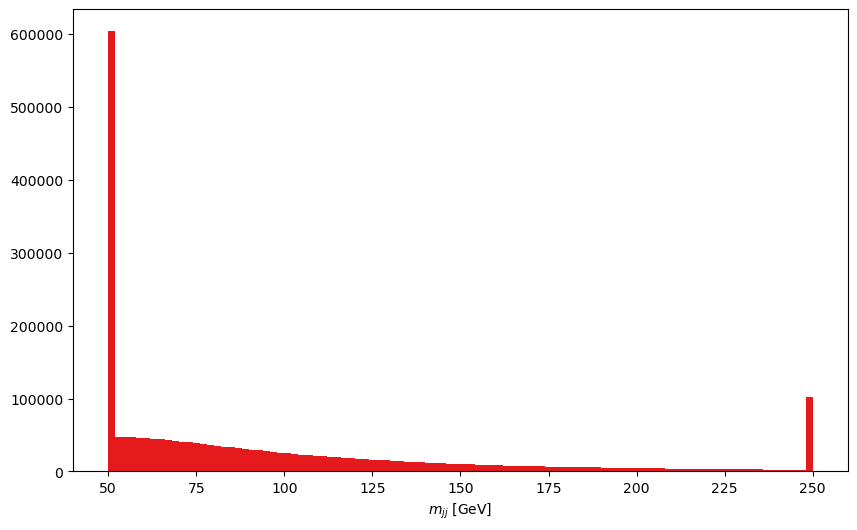

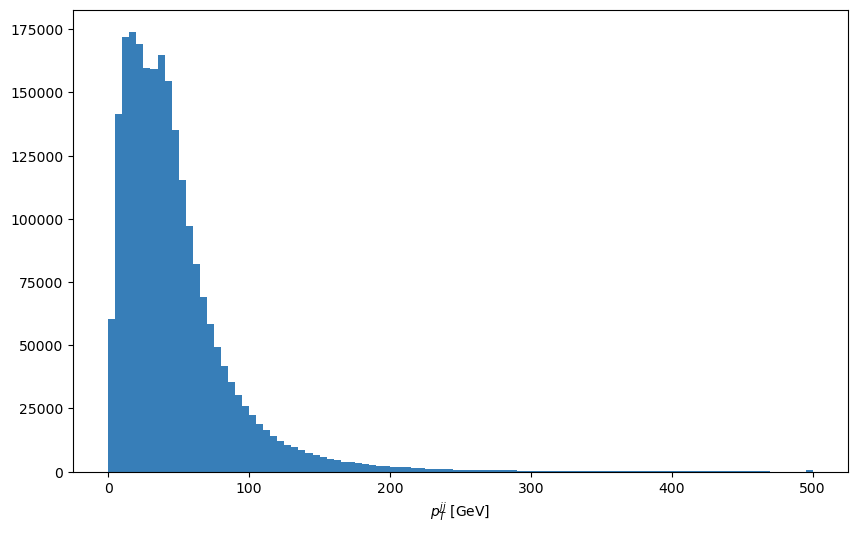

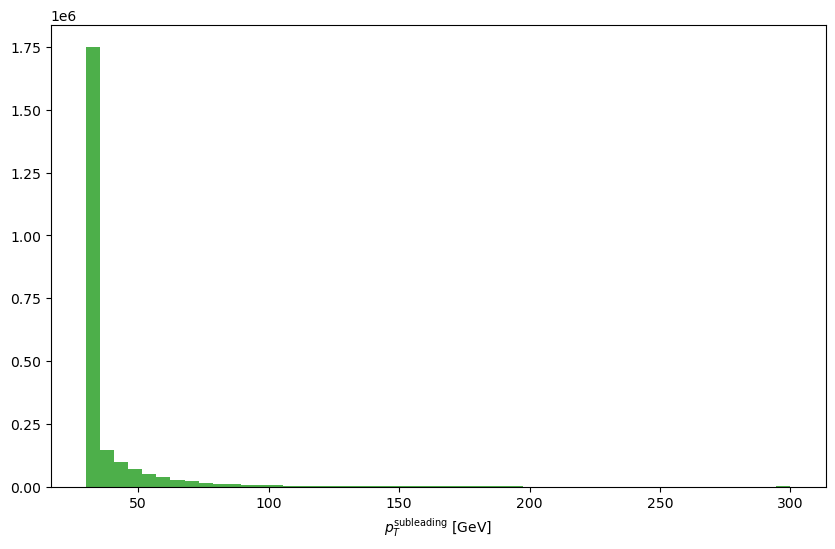

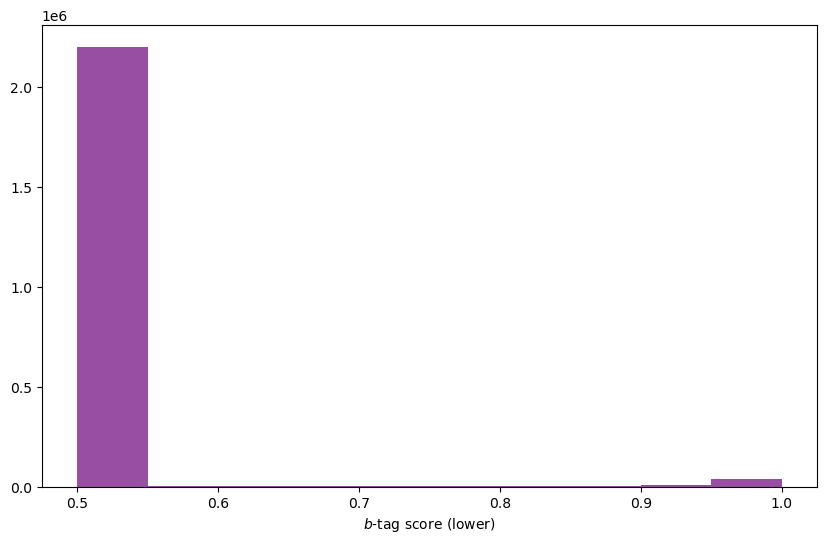

In [ ]:
# simple plotting loop
# mass_tight_b = hist_4d[{"lower_btag": slice(.8j, None)}].project("dijet_mass") 
for i, axis in enumerate(hist_4d.axes):
    fig, ax = plt.subplots(figsize=(10, 6)) 
    # ax.set_yscale('log')
    hist_4d[{"a": slice(0.0j, None)}].project(axis.name).plot1d(ax=ax, fill=True, label=axis.name, color=plt.colormaps['Set1'](i), flow='sum')
    plt.show()

    
# fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# for i, axis in enumerate(hist_4d.axes):
#     ax = axes[i // 2, i % 2]
#     ax.step(axis.centers, hist_4d.project(axis.name).values(), where='mid', linewidth=2, color=plt.colormaps['Set1'](i), alpha=0.8)
#     ax.fill_between(axis.centers, hist_4d.project(axis.name).values(), step='mid', alpha=0.3, color=plt.colormaps['Set1'](i))
#     ax.set_xlabel(axis.label, fontsize=12)

# plt.show()
